# Semantic Search in Research Papers

Semantic search over **50,000 ArXiv machine-learning papers** using
sentence-transformer embeddings and cosine similarity — finding papers by
*meaning*, not keywords.

**Pipeline:** title + abstract fusion → `all-MiniLM-L6-v2` embeddings (384-dim,
L2-normalized) → exact cosine search via a single matrix product → comparison
against keyword search → embedding-space visualization.

In [1]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.embed import combined_text, embed_corpus, get_model, load_corpus
from src.search import SemanticSearcher

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

## 1. Corpus

A 50k-paper sample of the [ML-ArXiv-Papers](https://huggingface.co/datasets/CShorten/ML-ArXiv-Papers)
dataset. Each document is the **title fused with the abstract** — titles carry
dense signal, abstracts add context, and embedding them together captures deeper
semantics than either alone.

In [2]:
df = load_corpus()
print(f"papers: {len(df):,}")
df["abstract_words"] = df["abstract"].str.split().str.len()
df.head(3)[["title"]]

papers: 50,000


,title
0,Invariant Representation Driven Neural Classifier for Anti-QCD Jet\n Tagging
1,"A Study of Domain Generalization on Ultrasound-based Multi-Class\n Segmentation of Arteries, Ve..."
2,Combinatorial Optimization with Physics-Inspired Graph Neural Networks


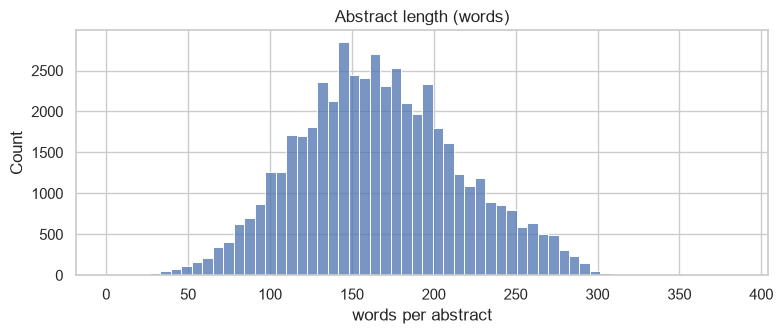

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(df["abstract_words"], bins=60, ax=ax)
ax.set_title("Abstract length (words)")
ax.set_xlabel("words per abstract")
plt.tight_layout()

## 2. Embedding the corpus

`all-MiniLM-L6-v2` maps each paper to a 384-dimensional vector. Embeddings are
**L2-normalized**, so cosine similarity is a plain dot product — searching all
50k papers is one matrix-vector multiplication (exact search; at this scale no
ANN index is needed).

In [4]:
model = get_model()
embeddings = embed_corpus(df, model)  # cached on disk after the first run
print(f"embeddings: {embeddings.shape}, dtype {embeddings.dtype}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embeddings: (50000, 384), dtype float32


## 3. Semantic search in action

In [5]:
searcher = SemanticSearcher(df, embeddings, model)

def show(query, top_k=5):
    results = searcher.search(query, top_k)
    results["title"] = results["title"].str.replace(r"\s+", " ", regex=True)
    print(f"query: {query!r}")
    return results[["similarity", "title"]]

show("how to detect fraudulent credit card transactions")

query: 'how to detect fraudulent credit card transactions'


,similarity,title
0,0.5680,Approaches to Fraud Detection on Credit Card Transactions Using Artificial Intelligence Methods
1,0.5667,The Importance of Future Information in Credit Card Fraud Detection
2,0.5525,Ensemble and Mixed Learning Techniques for Credit Card Fraud Detection
3,0.5459,BreachRadar: Automatic Detection of Points-of-Compromise
4,0.5372,FraudJudger: Real-World Data Oriented Fraud Detection on Digital Payment Platforms


In [6]:
show("making neural networks smaller and faster for mobile devices")

query: 'making neural networks smaller and faster for mobile devices'


,similarity,title
0,0.6334,NeuralScale: Efficient Scaling of Neurons for Resource-Constrained Deep Neural Networks
1,0.6268,On-Device Neural Net Inference with Mobile GPUs
2,0.6258,Low-rank Gradient Approximation For Memory-Efficient On-device Training of Deep Neural Network
3,0.6230,CoCoPIE: Making Mobile AI Sweet As PIE --Compression-Compilation Co-Design Goes a Long Way
4,0.6221,MoGA: Searching Beyond MobileNetV3


In [7]:
show("teaching robots to walk using trial and error")

query: 'teaching robots to walk using trial and error'


,similarity,title
0,0.5564,Teaching a Robot to Walk Using Reinforcement Learning
1,0.5210,Can Co-robots Learn to Teach?
2,0.5198,Teach Biped Robots to Walk via Gait Principles and Reinforcement Learning with Adversarial Critics
3,0.5188,Learning Flexible and Reusable Locomotion Primitives for a Microrobot
4,0.5179,Learning to Walk in the Real World with Minimal Human Effort


## 4. Why not keyword search?

The last query never says *reinforcement learning* — yet the results are RL
papers. A keyword search engine (TF-IDF) sees no overlap between
"trial and error" and "reinforcement learning". Side-by-side:

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = combined_text(df)
tfidf = TfidfVectorizer(stop_words="english", max_features=50_000)
tfidf_matrix = tfidf.fit_transform(texts)

def keyword_search(query, top_k=5):
    q = tfidf.transform([query])
    scores = cosine_similarity(q, tfidf_matrix)[0]
    idx = np.argsort(scores)[::-1][:top_k]
    out = df.iloc[idx][["title"]].copy()
    out.insert(0, "tfidf_score", scores[idx].round(4))
    out["title"] = out["title"].str.replace(r"\s+", " ", regex=True)
    return out.reset_index(drop=True)

query = "teaching robots to walk using trial and error"
keyword_search(query)

,tfidf_score,title
0,0.3935,Iterative Machine Teaching without Teachers
1,0.3900,An Overview of Machine Teaching
2,0.3623,Class Teaching for Inverse Reinforcement Learners
3,0.3620,Iterative Teaching by Label Synthesis
4,0.3317,Teaching to Learn: Sequential Teaching of Agents with Inner States


TF-IDF latches onto the literal words ("teaching", "walk", "error") and misses
the concept. The embedding model retrieves legged-locomotion RL papers because
it understands what the sentence *means*.

## 5. Related-paper recommendations

The same embeddings give "more like this" for free — nearest neighbours of any
paper in embedding space:

In [9]:
anchor = df[df["title"].str.contains("Attention", case=False)].index[0]
print("anchor:", " ".join(df.loc[anchor, "title"].split()))
sim = searcher.similar_papers(anchor)
sim["title"] = sim["title"].str.replace(r"\s+", " ", regex=True)
sim[["similarity", "title"]]

anchor: Semantic Segmentation With Multi Scale Spatial Attention For Self Driving Cars


,similarity,title
0,0.7684,Training of Convolutional Networks on Multiple Heterogeneous Datasets for Street Scene Semantic ...
1,0.7530,Semantic Segmentation for Urban-Scene Images
2,0.7287,EfficientPS: Efficient Panoptic Segmentation
3,0.7149,Multi-scale Attention U-Net (MsAUNet): A Modified U-Net Architecture for Scene Segmentation
4,0.7101,Impact of Ground Truth Annotation Quality on Performance of Semantic Image Segmentation of Traff...


## 6. Visualizing the embedding space

A 2-D t-SNE projection of 5,000 papers, colored by KMeans clusters found in the
full 384-dim space. Coherent research areas emerge without any labels.

In [10]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), 5000, replace=False)
sample_emb = embeddings[sample_idx]

kmeans = KMeans(n_clusters=8, random_state=42, n_init=4).fit(sample_emb)
xy = TSNE(n_components=2, random_state=42, init="pca", perplexity=40).fit_transform(sample_emb)

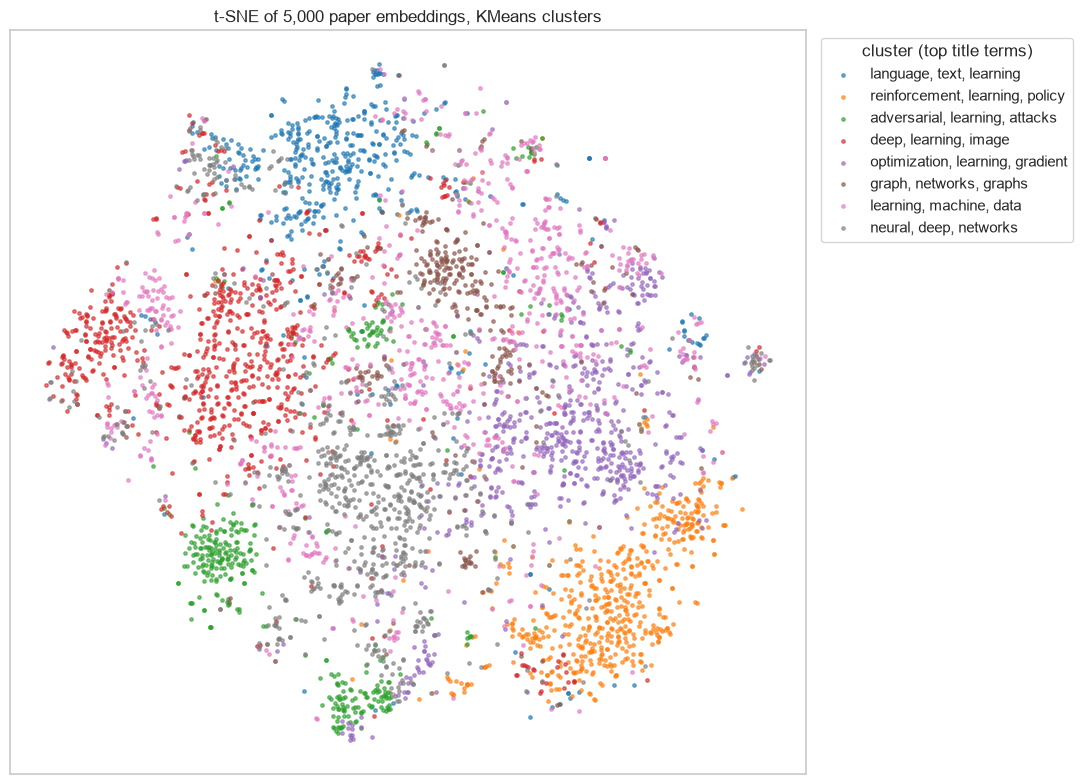

In [11]:
# Label each cluster by its most distinctive title words
cluster_tfidf = TfidfVectorizer(stop_words="english", max_features=20_000)
titles = df.iloc[sample_idx]["title"].str.replace(r"\s+", " ", regex=True)
tm = cluster_tfidf.fit_transform(titles)
vocab = np.array(cluster_tfidf.get_feature_names_out())
labels = {}
for c in range(8):
    mask = kmeans.labels_ == c
    top = np.asarray(tm[mask].mean(axis=0)).ravel().argsort()[::-1][:3]
    labels[c] = ", ".join(vocab[top])

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("tab10", 8)
for c in range(8):
    mask = kmeans.labels_ == c
    ax.scatter(xy[mask, 0], xy[mask, 1], s=6, alpha=0.6, color=palette[c], label=labels[c])
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="cluster (top title terms)")
ax.set_title("t-SNE of 5,000 paper embeddings, KMeans clusters")
ax.set_xticks([]), ax.set_yticks([])
plt.tight_layout()

## 7. Conclusions

* **Title + abstract fusion** gives each paper a single dense representation
  that captures its research content.
* At 50k documents, **exact cosine search** (one matrix product over normalized
  embeddings) answers a query in milliseconds — no vector database required.
* Semantic search **beats keyword search where it matters**: conceptual queries
  with zero term overlap still retrieve the right papers.
* The same embeddings power **related-paper recommendations** and reveal
  coherent research communities under t-SNE — one representation, three features.